# DS DataFrame Creation

In [2]:
import pandas as pd

### 1️⃣ Task: Create a Simple DataFrame

In [2]:
data1 = {
    "Name" : ["Nithis","Kumar","Hari","Sanjay","Praveen"],
    "Age" : [25,22,26,21,29],
    "Salary" : [100000,75000,90000,85000,65000]
}
data1

{'Name': ['Nithis', 'Kumar', 'Hari', 'Sanjay', 'Praveen'],
 'Age': [25, 22, 26, 21, 29],
 'Salary': [100000, 75000, 90000, 85000, 65000]}

In [3]:
df1 = pd.DataFrame(data1)
df1

,Name,Age,Salary
0,Nithis,25,100000
1,Kumar,22,75000
2,Hari,26,90000
3,Sanjay,21,85000
4,Praveen,29,65000


### 2️⃣ Task: Create a DataFrame from a List of Lists

In [4]:
data2 = [
    ["Nithis","Kumar","Hari","Sanjay","Praveen"],
    [25,22,26,21,29],
    [100000,75000,90000,85000,65000]
]

import numpy as np
data2 = np.transpose(data2)
data2

array([['Nithis', '25', '100000'],
       ['Kumar', '22', '75000'],
       ['Hari', '26', '90000'],
       ['Sanjay', '21', '85000'],
       ['Praveen', '29', '65000']], dtype='<U21')

In [5]:
df2 = pd.DataFrame(data2, columns = ["Name","Age","Salary"])
df2

,Name,Age,Salary
0,Nithis,25,100000
1,Kumar,22,75000
2,Hari,26,90000
3,Sanjay,21,85000
4,Praveen,29,65000


### 3️⃣ Task: Create a DataFrame with a Custom Index

In [6]:
df2["Employee Id"] = range(101,106)
df2

,Name,Age,Salary,Employee Id
0,Nithis,25,100000,101
1,Kumar,22,75000,102
2,Hari,26,90000,103
3,Sanjay,21,85000,104
4,Praveen,29,65000,105


In [7]:
df3 = df2.set_index("Employee Id")
df3

,Name,Age,Salary
Employee Id,,,
101,Nithis,25,100000
102,Kumar,22,75000
103,Hari,26,90000
104,Sanjay,21,85000
105,Praveen,29,65000


# DataFrame Manipulation Tasks

### 4️⃣ Task: Add a New Column to a DataFrame

In [8]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 101 to 105
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      object
 2   Salary  5 non-null      object
dtypes: object(3)
memory usage: 160.0+ bytes


In [9]:
df3["Salary"] = df3["Salary"].astype(float)
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 101 to 105
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    5 non-null      object 
 1   Age     5 non-null      object 
 2   Salary  5 non-null      float64
dtypes: float64(1), object(2)
memory usage: 160.0+ bytes


In [10]:
df3["Bonus"] = df3["Salary"] * 0.1
df3

,Name,Age,Salary,Bonus
Employee Id,,,,
101,Nithis,25,100000.0,10000.0
102,Kumar,22,75000.0,7500.0
103,Hari,26,90000.0,9000.0
104,Sanjay,21,85000.0,8500.0
105,Praveen,29,65000.0,6500.0


### 6️⃣ Task: Select Specific Columns

In [11]:
df3[["Name","Salary"]]

,Name,Salary
Employee Id,,
101,Nithis,100000.0
102,Kumar,75000.0
103,Hari,90000.0
104,Sanjay,85000.0
105,Praveen,65000.0


### 7️⃣ Task: Filter Rows Based on a Condition

In [12]:
df3[df3["Salary"] > 50000]

,Name,Age,Salary,Bonus
Employee Id,,,,
101,Nithis,25,100000.0,10000.0
102,Kumar,22,75000.0,7500.0
103,Hari,26,90000.0,9000.0
104,Sanjay,21,85000.0,8500.0
105,Praveen,29,65000.0,6500.0


In [13]:
df3[df3["Salary"] > 75000]

,Name,Age,Salary,Bonus
Employee Id,,,,
101,Nithis,25,100000.0,10000.0
103,Hari,26,90000.0,9000.0
104,Sanjay,21,85000.0,8500.0


In [14]:
df3["Ishigh"] = df3["Salary"].apply(lambda x : "high" if x > 75000 else "low")
df3

,Name,Age,Salary,Bonus,Ishigh
Employee Id,,,,,
101,Nithis,25,100000.0,10000.0,high
102,Kumar,22,75000.0,7500.0,low
103,Hari,26,90000.0,9000.0,high
104,Sanjay,21,85000.0,8500.0,high
105,Praveen,29,65000.0,6500.0,low


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Name', ylabel='Salary'>

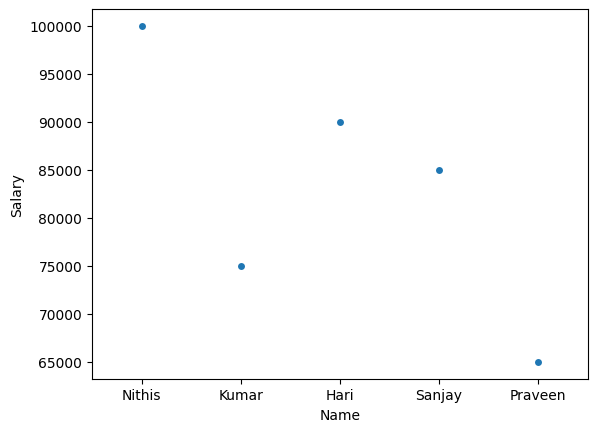

In [16]:
sns.swarmplot(x="Name", y="Salary", data=df3)

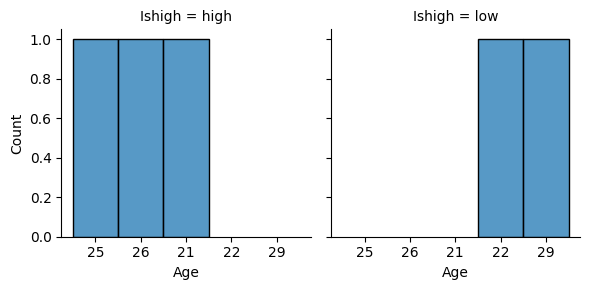

In [17]:
sns.FacetGrid(df3, col="Ishigh").map(sns.histplot, "Age")

In [19]:
data = pd.read_excel("class01.xlsx",index_col="Employee ID")
data

,Age,Salary,Bonus,Ishigh
Employee ID,,,,
100,23,140466,14046.6,1.0
101,45,123295,12329.5,1.0
102,45,164196,16419.6,1.0
103,32,157087,15708.7,1.0
104,27,134333,13433.3,1.0
...,...,...,...,...
587,32,94480,9448.0,NaN
588,33,63728,6372.8,NaN
589,24,59281,5928.1,NaN


In [20]:
from sklearn.semi_supervised import LabelSpreading
data.fillna(-1,inplace=True)
data

,Age,Salary,Bonus,Ishigh
Employee ID,,,,
100,23,140466,14046.6,1.0
101,45,123295,12329.5,1.0
102,45,164196,16419.6,1.0
103,32,157087,15708.7,1.0
104,27,134333,13433.3,1.0
...,...,...,...,...
587,32,94480,9448.0,-1.0
588,33,63728,6372.8,-1.0
589,24,59281,5928.1,-1.0


In [23]:
X=data.drop(["Age"],axis=1)
y=data["Ishigh"]
model = LabelSpreading(kernel='knn', n_neighbors=3)
model.fit(X, y)

,"kernel kernel: {'knn', 'rbf'} or callable, default='rbf'String identifier for kernel function to use or the kernel functionitself. Only 'rbf' and 'knn' strings are valid inputs. The functionpassed should take two inputs, each of shape (n_samples, n_features),and return a (n_samples, n_samples) shaped weight matrix.",'knn'
,"gamma gamma: float, default=20Parameter for rbf kernel.",20
,"n_neighbors n_neighbors: int, default=7Parameter for knn kernel which is a strictly positive integer.",3
,"alpha alpha: float, default=0.2Clamping factor. A value in (0, 1) that specifies the relative amountthat an instance should adopt the information from its neighbors asopposed to its initial label.alpha=0 means keeping the initial label information; alpha=1 meansreplacing all initial information.",0.2
,"max_iter max_iter: int, default=30Maximum number of iterations allowed.",30
,"tol tol: float, default=1e-3Convergence tolerance: threshold to consider the system at steadystate.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [30]:
data["Is_high"] = model.transduction_
data

,Age,Salary,Bonus,Is_high
Employee ID,,,,
100,23,140466,14046.6,1.0
101,45,123295,12329.5,1.0
102,45,164196,16419.6,1.0
103,32,157087,15708.7,1.0
104,27,134333,13433.3,1.0
...,...,...,...,...
587,32,94480,9448.0,1.0
588,33,63728,6372.8,0.0
589,24,59281,5928.1,0.0


In [31]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [35]:
from sklearn.tree import DecisionTreeClassifier
y_train= train_data["Is_high"]
y_test= test_data["Is_high"]
X_train=train_data.drop("Is_high", axis=1)
X_test=test_data.drop("Is_high",axis=1)
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [36]:
y_pred = model.predict(X_test)
y_pred

array([0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1.,
       1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1.,
       0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1.])

In [38]:
test_data["pred"] =y_pred
test_data

,Age,Salary,Bonus,Is_high,pred
Employee ID,,,,,
178,27,37198,3719.8,0.0,0.0
155,40,63083,6308.3,0.0,0.0
372,29,70618,7061.8,0.0,0.0
386,21,151492,15149.2,1.0,1.0
163,41,129273,12927.3,1.0,1.0
...,...,...,...,...,...
418,39,63558,6355.8,0.0,0.0
461,34,136164,13616.4,1.0,1.0
156,24,38900,3890.0,0.0,0.0


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [43]:
confusion_matrix(test_data["Is_high"],y_pred)

array([[37,  0],
       [ 1, 61]])

In [47]:
accuracy_score(test_data["Is_high"],y_pred) , precision_score(test_data["Is_high"],y_pred), recall_score(test_data["Is_high"],y_pred), f1_score(test_data["Is_high"],y_pred)

(0.98989898989899, 1.0, 0.9838709677419355, 0.991869918699187)

In [48]:
classification_report(test_data["Is_high"],y_pred)

'              precision    recall  f1-score   support\n\n         0.0       0.97      1.00      0.99        37\n         1.0       1.00      0.98      0.99        62\n\n    accuracy                           0.99        99\n   macro avg       0.99      0.99      0.99        99\nweighted avg       0.99      0.99      0.99        99\n'